# Belief-Aware LLMs — Evaluation Analysis
This notebook loads `eval_results.csv`, keeps the raw frame available as `df_raw`, and builds a cleaned analysis frame plus convenience slices for runs, models, and metrics.

In [101]:
from collections import defaultdict
import pandas as pd


CONDITION_COLUMNS = ['With_Store', 'Store_History', 'No_Store']


def load_eval_results(path='eval_results.csv', keep_runs=None, dedupe=True):
    df_raw = pd.read_csv(path)
    df_raw.columns = [c.strip() for c in df_raw.columns]

    alt_map = {
        'With_Store': ['With Store', 'with_store'],
        'Store_History': ['Store History', 'store_history'],
        'No_Store': ['No Store', 'no_store'],
    }
    rename_map = {}
    for canonical, aliases in alt_map.items():
        if canonical not in df_raw.columns:
            for alias in aliases:
                if alias in df_raw.columns:
                    rename_map[alias] = canonical
                    break
    if rename_map:
        df_raw = df_raw.rename(columns=rename_map)

    df = df_raw.copy()
    if 'Timestamp' in df.columns:
        df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
    if 'Runs' in df.columns:
        df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')
    if 'Temp' in df.columns:
        df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

    if keep_runs is not None and 'Runs' in df.columns:
        df = df[df['Runs'] == keep_runs].copy()

    if dedupe and {'Timestamp', 'Model', 'Domain', 'Prompt_Ver', 'Temp'}.issubset(df.columns):
        dedup_subset = ['Timestamp', 'Model', 'Domain', 'Prompt_Ver', 'Temp']
        if 'Summary_Metric' in df.columns:
            dedup_subset.append('Summary_Metric')
        df = df.sort_values('Timestamp').drop_duplicates(subset=dedup_subset, keep='last')

    condition_cols = [column for column in CONDITION_COLUMNS if column in df.columns]
    if condition_cols:
        id_vars = [column for column in df.columns if column not in condition_cols]
        df_melted = df.melt(
            id_vars=id_vars,
            value_vars=condition_cols,
            var_name='Condition',
            value_name='Value',
        ).dropna(subset=['Value']).copy()
        df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')
        df_melted = df_melted.dropna(subset=['Value']).copy()
    else:
        df_melted = df.copy()
        if 'Value' not in df_melted.columns:
            numeric_candidates = df_melted.select_dtypes(include='number').columns.tolist()
            if numeric_candidates:
                df_melted = df_melted.rename(columns={numeric_candidates[0]: 'Value'})
        if 'Condition' not in df_melted.columns:
            df_melted['Condition'] = 'value'

    if 'Summary_Metric' in df_melted.columns:
        df_acc = df_melted[df_melted['Summary_Metric'].eq('Average_Accuracy')].copy()
    else:
        df_acc = df_melted.copy()

    metric_names = df_melted['Summary_Metric'].dropna().astype(str).unique().tolist() if 'Summary_Metric' in df_melted.columns else []
    calib_metrics = [metric for metric in metric_names if 'calib' in metric.lower() or 'confidence' in metric.lower()]
    evidence_metrics = [metric for metric in metric_names if 'evidence' in metric.lower() or 'support' in metric.lower()]
    dfs_calib = {metric: df_melted[df_melted['Summary_Metric'] == metric].copy() for metric in calib_metrics}
    dfs_evidence = {metric: df_melted[df_melted['Summary_Metric'] == metric].copy() for metric in evidence_metrics}

    dfs_runs = {int(run): group.copy() for run, group in df_melted.groupby('Runs')} if 'Runs' in df_melted.columns else {}
    dfs_by_metric = {metric: group.copy() for metric, group in df_melted.groupby('Summary_Metric')} if 'Summary_Metric' in df_melted.columns else {}
    dfs_by_model = {model: group.copy() for model, group in df_melted.groupby('Model')} if 'Model' in df_melted.columns else {}

    return df_raw, df, df_acc, df_melted, dfs_calib, dfs_evidence, dfs_runs, dfs_by_metric, dfs_by_model

KEEP_RUNS = None
(df_raw, df, df_acc, df_melted, dfs_calib, dfs_evidence, dfs_runs, dfs_by_metric, dfs_by_model) = load_eval_results(keep_runs=KEEP_RUNS)

print('Raw rows:', len(df_raw))
print('Filtered rows:', len(df))
print('Melted rows:', len(df_melted))
print('Models:', df['Model'].nunique() if 'Model' in df.columns else 0)
print('Runs:', sorted(dfs_runs.keys()))

Raw rows: 3235
Filtered rows: 3156
Melted rows: 4808
Models: 5
Runs: [1, 2, 10]


### Quick usage examples
Use the raw frame for inspection, the cleaned frame for analysis, and `dfs_by_model` or `dfs_runs` for slicing by model or run count. The timestamp filter below shows how to pull rows for today.

In [102]:
# Quick usage examples
print('Raw rows:', len(df_raw))
print('Wide rows:', len(df))
print('Long rows:', len(df_melted))
print('Conditions:', sorted(df_melted['Condition'].dropna().astype(str).unique().tolist()) if 'Condition' in df_melted.columns else [])
print('Models:', sorted(df['Model'].dropna().astype(str).unique())[:10] if 'Model' in df.columns else [])
print('Runs:', sorted(df['Runs'].dropna().astype(int).unique()) if 'Runs' in df.columns else [])

if 'gemma4:e2b' in dfs_by_model:
    display(dfs_by_model['gemma4:e2b'].head())
elif dfs_by_model:
    first_model = next(iter(dfs_by_model))
    display(dfs_by_model[first_model].head())

if 'Timestamp' in df.columns:
    today = pd.Timestamp.today().normalize()
    today_rows = df[df['Timestamp'].dt.normalize() == today]
    display(today_rows[['Timestamp', 'Model', 'Domain', 'Runs', 'Summary_Metric']].head(20))

Raw rows: 3235
Wide rows: 3156
Long rows: 4808
Conditions: ['No_Store', 'With_Store']
Models: ['gemma3:1b', 'gemma4:e2b', 'hoangquan456/qwen3-nothink:4b', 'llama3.2:1b', 'ministral-3:3b']
Runs: [np.int64(1), np.int64(2), np.int64(10)]


,Timestamp,Domain,Model,Temp,Prompt_Ver,Runs,Summary_Metric,Class_Label,Condition,Value
324,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Canonical_Keys,NaN,With_Store,12.3000
325,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Cited_Keys,NaN,With_Store,4.9000
326,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_F1,NaN,With_Store,0.4043
327,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Recall,NaN,With_Store,0.2877
328,2026-05-09 00:09:09,loan,gemma4:e2b,0.0,v15,1,Average_Evidence_Precision,NaN,With_Store,0.7112


,Timestamp,Model,Domain,Runs,Summary_Metric


### Metrics comparison
This cell compares all models for rows with `Runs == 1` on today's date and draws a heatmap from the first numeric metric column it finds.

In [103]:
# Metrics comparison for Runs == 1 on today's date
import matplotlib.pyplot as plt
import seaborn as sns

TARGET_DATE = pd.Timestamp.today().normalize()

src = df.copy()
if 'Timestamp' in src.columns:
    src['Timestamp'] = pd.to_datetime(src['Timestamp'], errors='coerce')
if 'Runs' in src.columns:
    src['Runs'] = pd.to_numeric(src['Runs'], errors='coerce')

runs_today = src[(src['Runs'] == 1) & (src['Timestamp'].dt.normalize() == TARGET_DATE)].copy()
print(f'Results for {TARGET_DATE.date()} (Runs == 1):')

if runs_today.empty:
    print('No rows found for Runs == 1 on the selected date.')
    display(src.sort_values('Timestamp', ascending=False).head(25))
else:
    condition_cols = [column for column in ['With_Store', 'Store_History', 'No_Store'] if column in runs_today.columns]
    metric_col = None
    if 'Value' in runs_today.columns:
        metric_col = 'Value'
    elif condition_cols:
        metric_col = condition_cols[0]
    else:
        numeric_cols = runs_today.select_dtypes(include='number').columns.tolist()
        numeric_cols = [column for column in numeric_cols if column not in ['Runs', 'Temp']]
        if numeric_cols:
            metric_col = numeric_cols[0]

    if metric_col is None:
        raise RuntimeError('No numeric metric column found for comparison.')

    pivot = runs_today.pivot_table(index='Summary_Metric', columns='Model', values=metric_col, aggfunc='first').sort_index()
    display(pivot)

    if not pivot.empty:
        plt.figure(figsize=(max(8, pivot.shape[1] * 0.8), max(3, pivot.shape[0] * 0.45)))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='vlag', center=0, cbar_kws={'label': metric_col})
        plt.title(f'Runs == 1 on {TARGET_DATE.date()}')
        plt.xlabel('Model')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

Results for 2026-05-11 (Runs == 1):
No rows found for Runs == 1 on the selected date.


,Timestamp,Domain,Model,Temp,Prompt_Ver,Runs,Summary_Metric,With_Store,Store_History,No_Store,Class_Label
3234,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Average_SBIR_SpuriousInjection,0.290000,NaN,NaN,NaN
3218,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,DS_Determinism_Score,0.900000,NaN,0.900000,NaN
3225,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Summary_Metric_ECE,0.153014,NaN,0.719322,NaN
3226,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,EMD_WithStore_bracketed_exact,1.000000,NaN,NaN,NaN
3227,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,EMD_NoStore_bracketed_exact,1.000000,NaN,NaN,NaN
3232,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Average_Evidence_Canonical_Keys,2.600000,NaN,NaN,NaN
3229,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Average_Evidence_Recall,0.000000,NaN,NaN,NaN
3230,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Average_Evidence_F1,0.000000,NaN,NaN,NaN
3224,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Summary_Metric_Log_Loss,0.651649,NaN,1.885080,NaN
3228,2026-05-10 23:07:57,thorncrester_belief_maintenance,llama3.2:1b,0.0,v16,1,Average_Evidence_Precision,0.000000,NaN,NaN,NaN


## 1. Stability & Noise Reduction Analysis (AFR & DS)
**Claim:** The belief store reduces sampling noise and makes the LLM more deterministic.
*   **Plot:** A comparative bar chart showing the **Answer Flip Rate (AFR)** and **Determinism Score (DS)** for `With_Store` vs. `No_Store` across all models (filtered for `Runs > 1`).
*   **Value:** Proves that even when models hallucinate, the belief store forces them to be internally consistent.

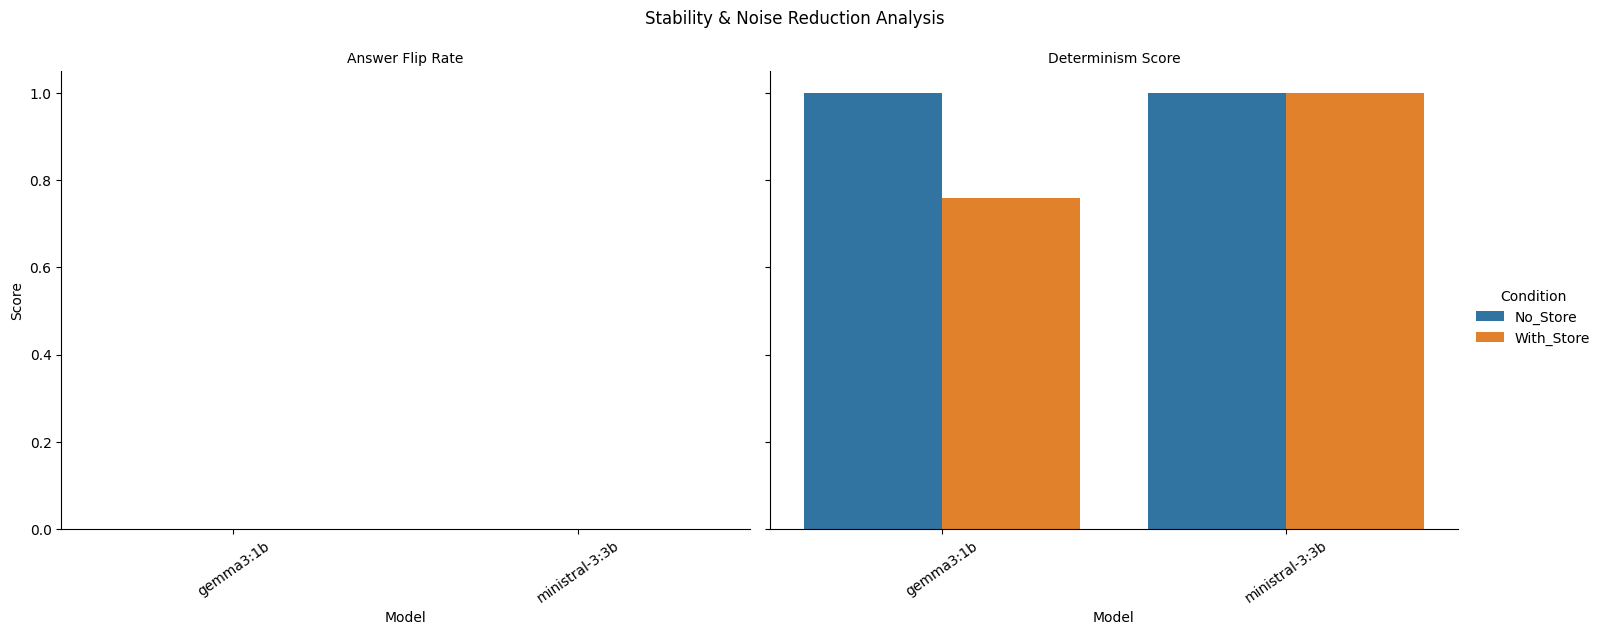

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

metric_labels = {
    'AFR_Answer_Flip_Rate': 'Answer Flip Rate',
    'DS_Determinism_Score': 'Determinism Score',
}

stability_df = df_melted[
    (df_melted['Runs'] > 1)
    & df_melted['Summary_Metric'].isin(metric_labels)
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if stability_df.empty:
    print('Not enough data with Runs > 1 for AFR and DS metrics.')
else:
    stability_df['Metric_Label'] = stability_df['Summary_Metric'].map(metric_labels)
    summary = stability_df.groupby(['Metric_Label', 'Model', 'Condition'], as_index=False)['Value'].mean()
    g = sns.catplot(
        data=summary,
        kind='bar',
        x='Model',
        y='Value',
        hue='Condition',
        col='Metric_Label',
        height=5.5,
        aspect=1.35,
    )
    g.set_axis_labels('Model', 'Score')
    g.set_titles('{col_name}')
    g.fig.suptitle('Stability & Noise Reduction Analysis', y=1.05)
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=35)
    plt.show()

## 2. Prior Suppression (The `absurd` Domains)
**Claim:** The belief store successfully overrides the LLM's parametric priors.
*   **Plot:** A grouped bar chart comparing `Average_Accuracy` on all `_absurd` scenarios.
*   **Value:** The delta between `With_Store` and `No_Store` here is the defining proof of Belief-Awareness.

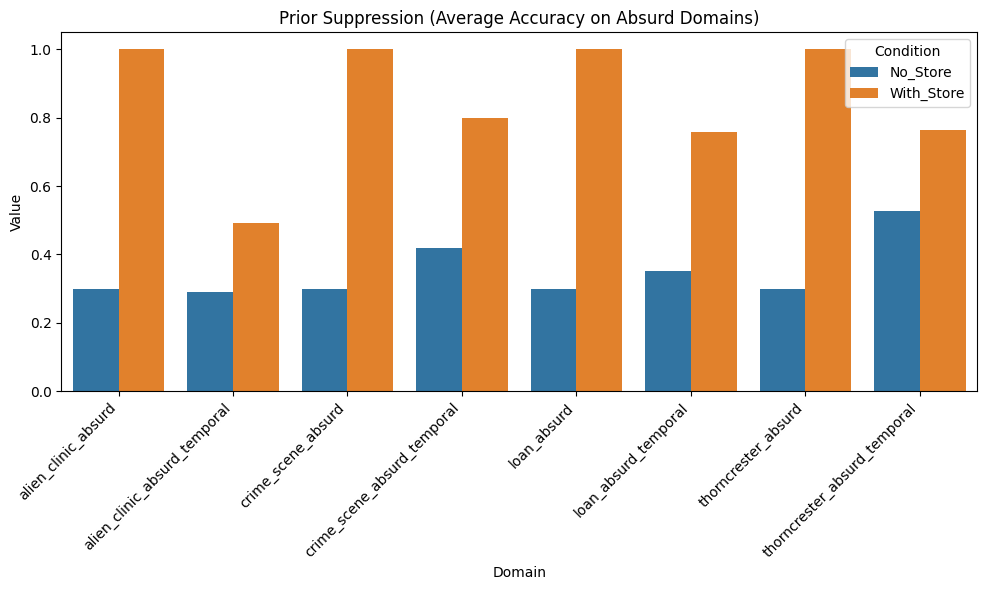

In [105]:
absurd_df = df_melted[
    df_melted['Domain'].str.contains('_absurd', na=False)
    & df_melted['Summary_Metric'].eq('Average_Accuracy')
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if absurd_df.empty:
    print('No data found for absurd domains.')
else:
    summary = absurd_df.groupby(['Domain', 'Condition'], as_index=False)['Value'].mean()
    domain_order = sorted(summary['Domain'].dropna().astype(str).unique().tolist())

    plt.figure(figsize=(max(10, len(domain_order) * 1.1), 6))
    sns.barplot(data=summary, x='Domain', y='Value', hue='Condition', order=domain_order)
    plt.title('Prior Suppression (Average Accuracy on Absurd Domains)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Context Stability (The `belief_maintenance` Domains)
**Claim:** The Belief Engine (HopWalker) shields the LLM from accumulating distractor facts.
*   **Plot:** A heatmap or trendline showing accuracy on `belief_maintenance` domains across the different models.
*   **Value:** Proves that the system doesn't degrade as the conversational context window fills up with irrelevant facts.

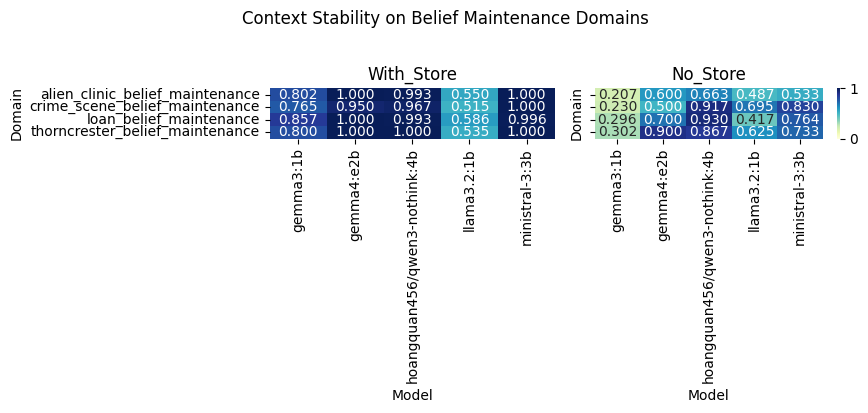

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

context_df = df_melted[
    df_melted['Domain'].str.contains('belief_maintenance', na=False)
    & df_melted['Summary_Metric'].eq('Average_Accuracy')
    & df_melted['Condition'].isin(['With_Store', 'No_Store'])
].copy()

if context_df.empty:
    print('No belief_maintenance accuracy data found.')
else:
    summary = context_df.groupby(['Domain', 'Model', 'Condition'], as_index=False)['Value'].mean()
    domain_order = sorted(summary['Domain'].dropna().astype(str).unique().tolist())
    condition_order = [condition for condition in ['With_Store', 'No_Store'] if condition in summary['Condition'].unique()]

    fig, axes = plt.subplots(
        1,
        len(condition_order),
        figsize=(max(8, 4.5 * len(condition_order)), max(4, 0.55 * len(domain_order))),
        sharey=True,
    )
    if len(condition_order) == 1:
        axes = [axes]

    for index, (ax, condition) in enumerate(zip(axes, condition_order)):
        pivot = (
            summary[summary['Condition'] == condition]
            .pivot(index='Domain', columns='Model', values='Value')
            .reindex(domain_order)
        )
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.3f',
            cmap='YlGnBu',
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=index == len(condition_order) - 1,
        )
        ax.set_title(condition)
        ax.set_xlabel('Model')
        ax.set_ylabel('Domain')

    fig.suptitle('Context Stability on Belief Maintenance Domains', y=1.02)
    plt.tight_layout()
    plt.show()

## 4. Efficiency Analysis (TPCA & WCT)
**Claim:** The belief store creates more concise, directed reasoning.
*   **Plot:** Scatter plot of **Tokens Per Correct Answer (TPCA)** vs. Accuracy, colored by Model and Store Condition.
*   **Value:** Visually demonstrates that `With_Store` leads to shorter, more precise answers compared to `No_Store` (which likely rambles or hallucinates longer responses).

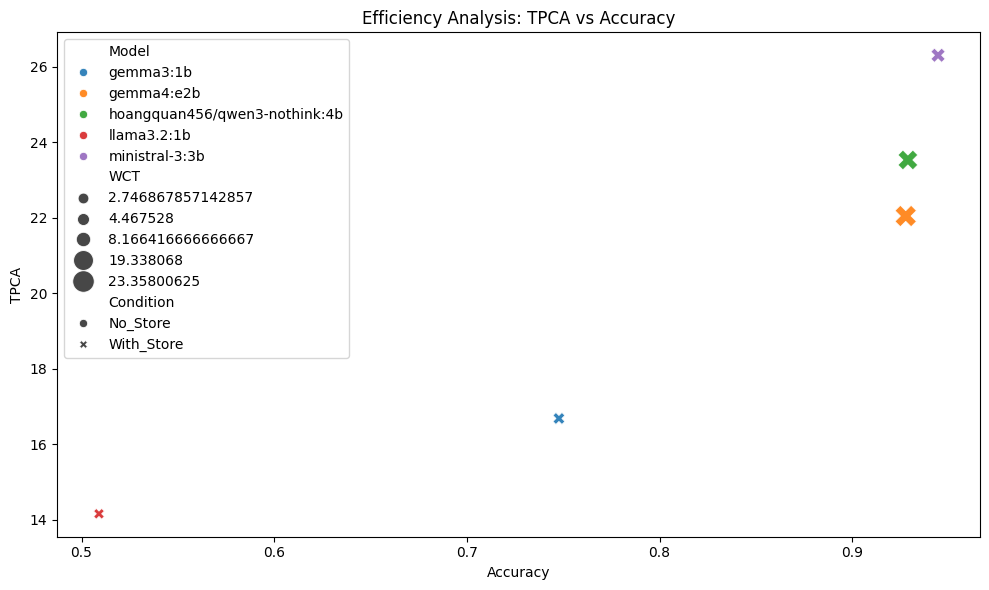

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_df = (
    df_melted[df_melted['Summary_Metric'].eq('Average_Accuracy')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'Accuracy'})
)

tpca_df = (
    df_melted[df_melted['Summary_Metric'].eq('TPCA_Words_Correct')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'TPCA'})
)

wct_df = (
    df_melted[df_melted['Summary_Metric'].eq('WCT_WallClock_PerTurn_Seconds')]
    .groupby(['Model', 'Condition'], as_index=False)['Value']
    .mean()
    .rename(columns={'Value': 'WCT'})
)

eff_df = accuracy_df.merge(tpca_df, on=['Model', 'Condition'], how='inner').merge(wct_df, on=['Model', 'Condition'], how='left')

if eff_df.empty:
    print('Not enough data for TPCA vs Accuracy scatter plot.')
else:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=eff_df,
        x='Accuracy',
        y='TPCA',
        hue='Model',
        style='Condition',
        size='WCT',
        sizes=(60, 240),
        alpha=0.9,
    )
    plt.title('Efficiency Analysis: TPCA vs Accuracy')
    plt.tight_layout()
    plt.show()

## 5. Retrieval Fidelity Check (BCR)
**Claim:** Upstream graph extraction never dropped required facts.
*   **Table:** A simple validation table confirming that **Belief Coverage Rate (BCR)** is 1.0 across all runs.

In [108]:
from IPython.display import display

bcr_df = df_melted[df_melted['Summary_Metric'].eq('Average_BCR_BeliefCoverage')].copy()

if bcr_df.empty:
    print('No BCR data found.')
else:
    bcr_summary = (
        bcr_df.groupby(['Model', 'Condition'], as_index=False)['Value']
        .agg(['mean', 'min', 'max', 'count'])
        .reset_index()
    )
    print('Belief Coverage Rate (BCR) Summary:')
    display(bcr_summary)

    if (bcr_df['Value'] == 1.0).all():
        print('\nSuccess: BCR is 1.0 across all runs.')
    else:
        print('\nWarning: BCR is not 1.0 for all runs.')
        display(bcr_df[bcr_df['Value'] != 1.0][['Timestamp', 'Domain', 'Model', 'Condition', 'Value']].head(20))

Belief Coverage Rate (BCR) Summary:


,index,Model,Condition,mean,min,max,count
0,0,gemma3:1b,With_Store,1.0,1.0,1.0,25
1,1,gemma4:e2b,With_Store,1.0,1.0,1.0,16
2,2,hoangquan456/qwen3-nothink:4b,With_Store,1.0,1.0,1.0,50
3,3,llama3.2:1b,With_Store,1.0,1.0,1.0,28
4,4,ministral-3:3b,With_Store,1.0,1.0,1.0,18



Success: BCR is 1.0 across all runs.


In [121]:
# Compare With_Store vs baseline (No_Store) on calibration metrics, per model
from IPython.display import display

baseline_condition = 'No_Store'
store_condition = 'With_Store'

metric_aliases = {
    'ECE': ['Average_Calibration_ECE', 'ECE', 'Expected_Calibration_Error'],
    'Brier': ['Average_Calibration_Brier', 'Brier', 'Brier_Score'],
}

if 'Summary_Metric' not in df_melted.columns or 'Condition' not in df_melted.columns:
    print('Required columns (Summary_Metric, Condition) are missing in df_melted.')
else:
    available_metrics = set(df_melted['Summary_Metric'].dropna().astype(str).unique().tolist())
    selected_metric_map = {}
    for label, candidates in metric_aliases.items():
        for candidate in candidates:
            if candidate in available_metrics:
                selected_metric_map[label] = candidate
                break

    if len(selected_metric_map) < 2:
        print('Could not find both ECE and Brier metrics in this dataset.')
        print('Found calibration-like metrics:')
        calib_like = [m for m in sorted(available_metrics) if 'calib' in m.lower() or 'ece' in m.lower() or 'brier' in m.lower()]
        print(calib_like)
    else:
        metric_names = list(selected_metric_map.values())
        filtered = df_melted[
            df_melted['Summary_Metric'].isin(metric_names)
            & df_melted['Condition'].isin([baseline_condition, store_condition])
        ].copy()

        if filtered.empty:
            print('No rows available for baseline vs with-store comparison on ECE/Brier.')
        else:
            filtered['Metric_Label'] = filtered['Summary_Metric'].map({v: k for k, v in selected_metric_map.items()})
            filtered['Model_Display'] = filtered['Model'].replace({
                'hoangquan456/qwen3-nothink:4b': 'hoangquan/qwen3-nothink:4b'
            })

            model_metric_condition = (
                filtered.groupby(['Model_Display', 'Metric_Label', 'Condition'], as_index=False)['Value']
                .mean()
            )

            pivot = model_metric_condition.pivot_table(
                index=['Model_Display', 'Metric_Label'],
                columns='Condition',
                values='Value',
                aggfunc='mean'
            ).reset_index()

            for condition in [baseline_condition, store_condition]:
                if condition not in pivot.columns:
                    pivot[condition] = pd.NA

            pivot['Delta_(With_Store-Baseline)'] = pivot[store_condition] - pivot[baseline_condition]
            pivot['Pct_Delta_vs_Baseline'] = (pivot['Delta_(With_Store-Baseline)'] / pivot[baseline_condition]) * 100

            comparison_table = pivot[
                [
                    'Model_Display',
                    'Metric_Label',
                    baseline_condition,
                    store_condition,
                    'Delta_(With_Store-Baseline)',
                    'Pct_Delta_vs_Baseline',
                ]
            ].sort_values(['Model_Display', 'Metric_Label']).reset_index(drop=True)

            print('With_Store vs baseline (No_Store) by model for ECE and Brier:')
            display(comparison_table)

            # Lower is better for both ECE and Brier; negative deltas indicate improvement.
            print('\nPer-model wide summary (negative delta = improvement):')
            wide_summary = comparison_table.pivot_table(
                index='Model_Display',
                columns='Metric_Label',
                values='Delta_(With_Store-Baseline)',
                aggfunc='first'
            )
            display(wide_summary)

With_Store vs baseline (No_Store) by model for ECE and Brier:


Condition,Model_Display,Metric_Label,No_Store,With_Store,Delta_(With_Store-Baseline),Pct_Delta_vs_Baseline
0,gemma3:1b,Brier,0.657200,0.120327,-0.536873,-81.690920
1,gemma3:1b,ECE,0.711191,0.120227,-0.590964,-83.094937
2,gemma4:e2b,Brier,0.100000,0.000000,-0.100000,-100.000000
3,gemma4:e2b,ECE,0.100000,0.000000,-0.100000,-100.000000
4,hoangquan/qwen3-nothink:4b,Brier,0.058100,0.006200,-0.051900,-89.328744
5,hoangquan/qwen3-nothink:4b,ECE,0.062125,0.016325,-0.045800,-73.722334
6,llama3.2:1b,Brier,0.444800,0.348925,-0.095875,-21.554631
7,llama3.2:1b,ECE,0.480900,0.360150,-0.120750,-25.109170
8,ministral-3:3b,Brier,0.469325,0.007675,-0.461650,-98.364673
9,ministral-3:3b,ECE,0.470650,0.018475,-0.452175,-96.074578



Per-model wide summary (negative delta = improvement):


Metric_Label,Brier,ECE
Model_Display,,
gemma3:1b,-0.536873,-0.590964
gemma4:e2b,-0.100000,-0.100000
hoangquan/qwen3-nothink:4b,-0.051900,-0.045800
llama3.2:1b,-0.095875,-0.120750
ministral-3:3b,-0.461650,-0.452175


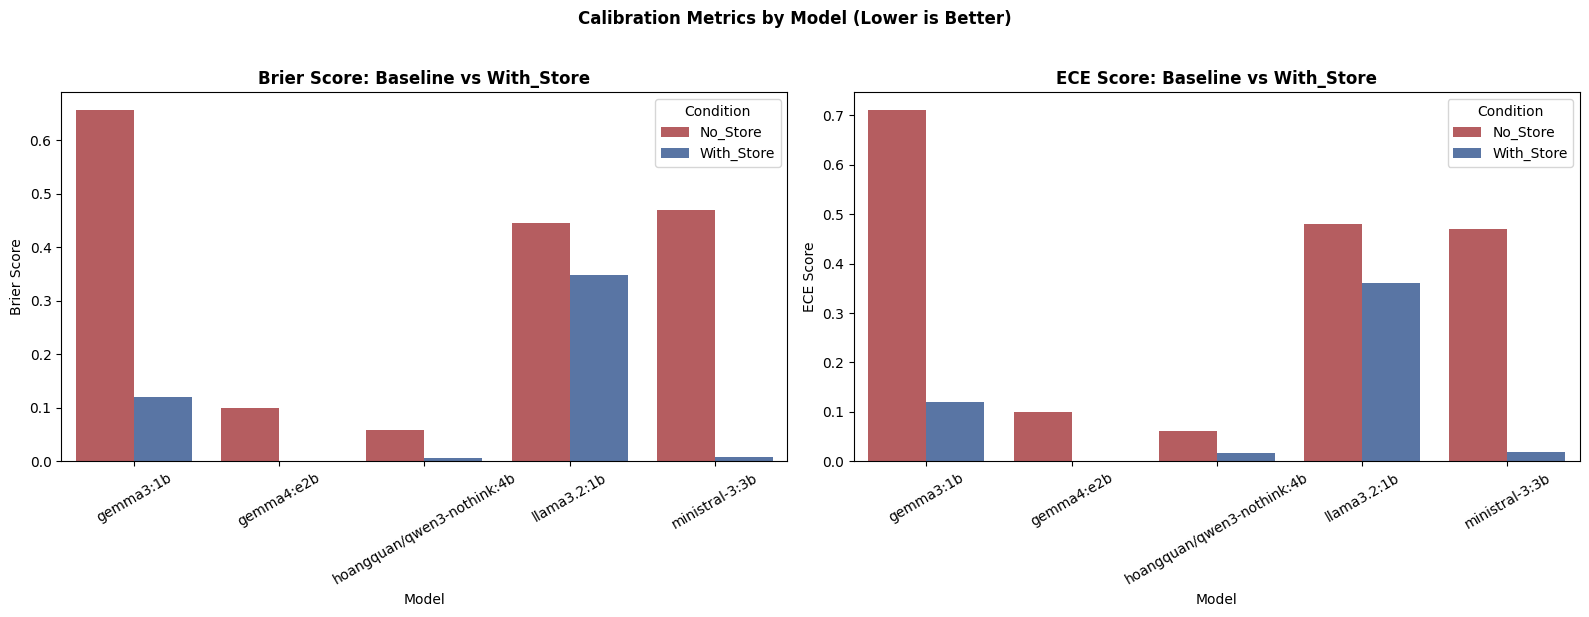

✓ Created two charts: Brier and ECE (baseline vs with-store)


In [123]:
# Two charts: baseline vs with-store for Brier and ECE separately
if 'comparison_table' not in globals() or comparison_table.empty:
    print('comparison_table is not available. Run the previous comparison cell first.')
else:
    plot_df = comparison_table.copy()

    needed_cols = ['Model_Display', 'Metric_Label', 'No_Store', 'With_Store']
    missing_cols = [c for c in needed_cols if c not in plot_df.columns]
    if missing_cols:
        print(f'Missing required columns: {missing_cols}')
    else:
        # Convert to long format so each chart can compare No_Store vs With_Store directly.
        long_df = plot_df.melt(
            id_vars=['Model_Display', 'Metric_Label'],
            value_vars=['No_Store', 'With_Store'],
            var_name='Condition',
            value_name='Score',
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

        for idx, metric in enumerate(['Brier', 'ECE']):
            metric_df = long_df[long_df['Metric_Label'] == metric].copy()

            if metric_df.empty:
                axes[idx].text(0.5, 0.5, f'No data for {metric}', ha='center', va='center')
                axes[idx].set_title(f'{metric}: Baseline vs With_Store')
                axes[idx].set_axis_off()
                continue

            sns.barplot(
                data=metric_df,
                x='Model_Display',
                y='Score',
                hue='Condition',
                hue_order=['No_Store', 'With_Store'],
                palette={'No_Store': '#C44E52', 'With_Store': '#4C72B0'},
                ax=axes[idx],
            )
            axes[idx].set_title(f'{metric} Score: Baseline vs With_Store', fontweight='bold')
            axes[idx].set_xlabel('Model')
            axes[idx].set_ylabel(f'{metric} Score')
            axes[idx].tick_params(axis='x', rotation=30)
            axes[idx].legend(title='Condition', loc='best')

        plt.suptitle('Calibration Metrics by Model (Lower is Better)', fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()
        print('✓ Created two charts: Brier and ECE (baseline vs with-store)')

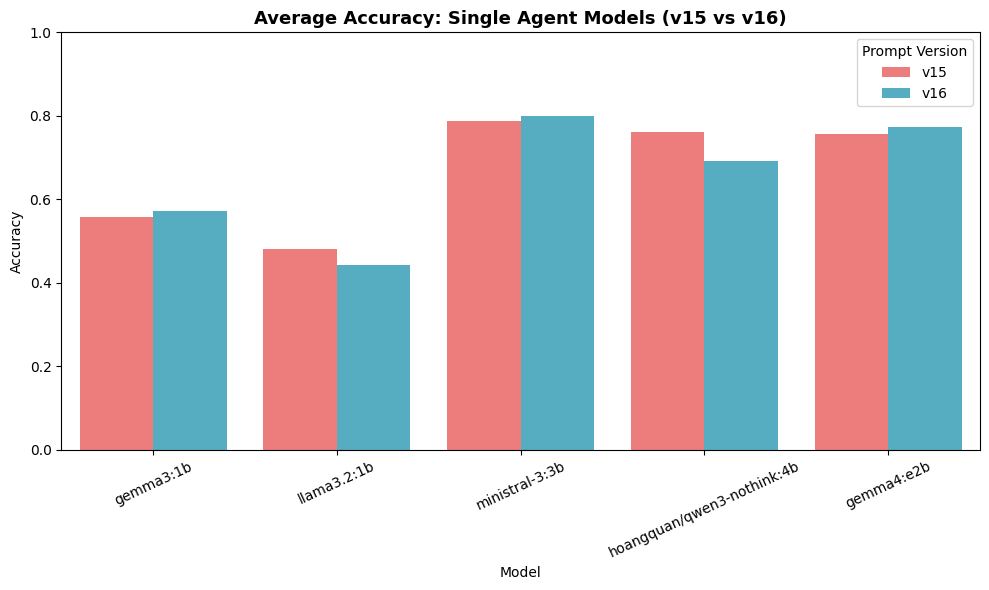

✓ Accuracy comparison created


In [109]:
# 6.1 Average Accuracy by Model: v15 vs v16
accuracy_data = []
for model in df_v15v16['Model_Display'].dropna().unique():
    for version in ['v15', 'v16']:
        subset = df_v15v16[
            (df_v15v16['Summary_Metric'] == 'Average_Accuracy') & 
            (df_v15v16['Prompt_Ver'] == version) &
            (df_v15v16['Model_Display'] == model)
        ]['Value'].dropna().tolist()
        if subset:
            accuracy_data.append({
                'Model': model,
                'Version': version, 
                'Accuracy': np.mean(subset),
                'Std': np.std(subset)
            })

if accuracy_data:
    acc_df = pd.DataFrame(accuracy_data)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=acc_df, x='Model', y='Accuracy', hue='Version', 
                palette=['#FF6B6B', '#45B7D1'], ax=ax)
    ax.set_title('Average Accuracy: Single Agent Models (v15 vs v16)', 
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Prompt Version')
    plt.tight_layout()
    plt.show()
    print("✓ Accuracy comparison created")
else:
    print("No accuracy data found for v15/v16")


Generating heatmap visualization...



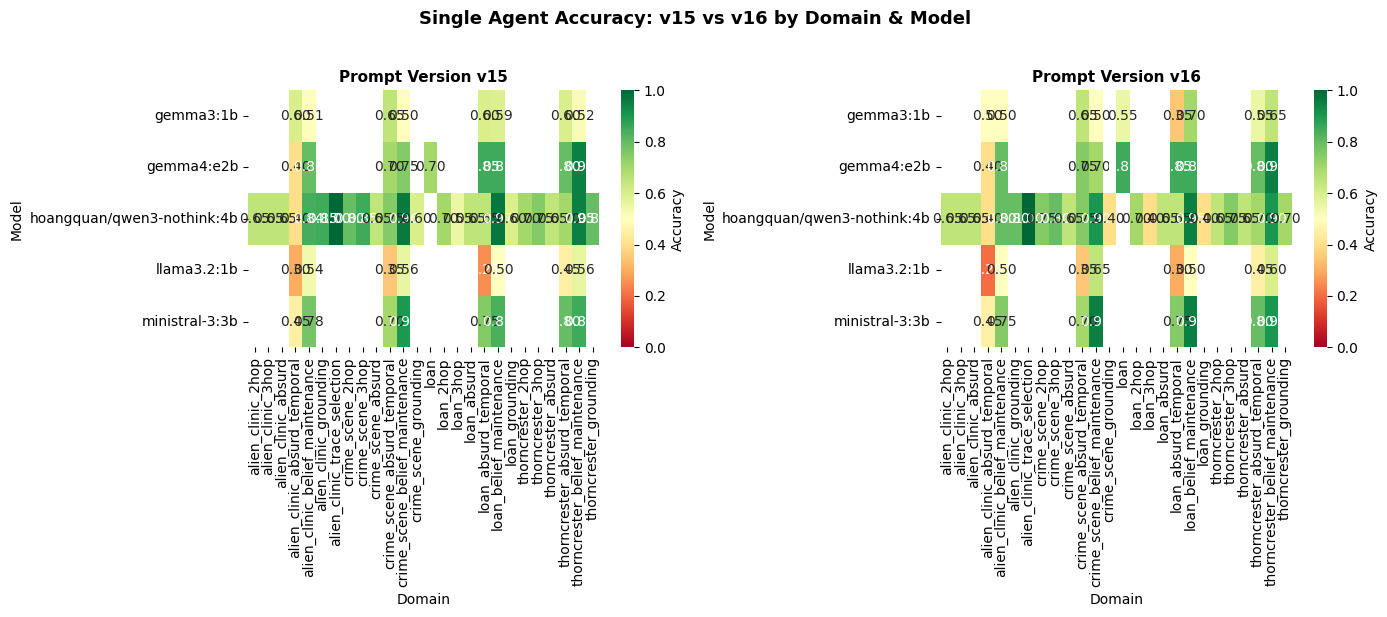

✓ Heatmap visualization created


In [110]:
# 6.7 Heatmap: Model Performance Across Domains (v15 vs v16)
print("\nGenerating heatmap visualization...\n")

model_domain_data = []
for model in df_v15v16['Model_Display'].dropna().unique():
    for domain in df_v15v16['Domain'].unique():
        for version in ['v15', 'v16']:
            subset = df_v15v16[
                (df_v15v16['Domain'] == domain) &
                (df_v15v16['Model_Display'] == model) &
                (df_v15v16['Prompt_Ver'] == version) &
                (df_v15v16['Summary_Metric'] == 'Average_Accuracy')
            ]['Value'].dropna().tolist()
            
            if subset:
                model_domain_data.append({
                    'Model': model,
                    'Domain': domain,
                    'Version': version,
                    'Accuracy': np.mean(subset)
                })

if model_domain_data:
    md_df = pd.DataFrame(model_domain_data)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    for idx, version in enumerate(['v15', 'v16']):
        version_data = md_df[md_df['Version'] == version]
        heatmap_data = version_data.pivot_table(
            index='Model',
            columns='Domain',
            values='Accuracy'
        )
        
        if not heatmap_data.empty:
            sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
                       ax=axes[idx], cbar_kws={'label': 'Accuracy'},
                       vmin=0, vmax=1)
            axes[idx].set_title(f'Prompt Version {version}', fontsize=11, fontweight='bold')
    
    plt.suptitle('Single Agent Accuracy: v15 vs v16 by Domain & Model', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print("✓ Heatmap visualization created")
else:
    print("No model-domain data available")

In [111]:
# 6.6 Summary Table: All Key Metrics v15 vs v16
print("\n" + "="*100)
print("COMPREHENSIVE METRICS SUMMARY: SINGLE AGENT MODELS (v15 vs v16)")
print("="*100 + "\n")

key_metrics = [
    'Average_Accuracy',
    'Average_F1_Macro',
    'Variance_Raw_Score',
    'StdDev_Raw_Score',
    'Variance_F1_Macro'
]

all_summary = []

for metric in key_metrics:
    for version in ['v15', 'v16']:
        subset = df_v15v16[
            (df_v15v16['Summary_Metric'] == metric) & 
            (df_v15v16['Prompt_Ver'] == version)
        ]['Value'].dropna().tolist()
        
        if subset:
            all_summary.append({
                'Metric': metric,
                'Version': version,
                'Mean': np.mean(subset),
                'Std Dev': np.std(subset),
                'Min': np.min(subset),
                'Max': np.max(subset),
                'Count': len(subset)
            })

summary_table = pd.DataFrame(all_summary)
comparison = []
for metric in key_metrics:
    metric_group = summary_table[summary_table['Metric'] == metric]
    v15_data = metric_group[metric_group['Version'] == 'v15']
    v16_data = metric_group[metric_group['Version'] == 'v16']
    
    if not v15_data.empty and not v16_data.empty:
        v15_mean = v15_data['Mean'].values[0]
        v16_mean = v16_data['Mean'].values[0]
        change = v16_mean - v15_mean
        pct_change = (change / v15_mean * 100) if v15_mean != 0 else 0
        
        comparison.append({
            'Metric': metric,
            'v15 Mean': round(v15_mean, 4),
            'v16 Mean': round(v16_mean, 4),
            'Change': round(change, 4),
            'Change %': round(pct_change, 2)
        })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))
print("\n" + "="*100)


COMPREHENSIVE METRICS SUMMARY: SINGLE AGENT MODELS (v15 vs v16)

            Metric  v15 Mean  v16 Mean  Change  Change %
  Average_Accuracy    0.6659    0.6389 -0.0270     -4.06
Variance_Raw_Score    0.2119    0.0000 -0.2119   -100.00
  StdDev_Raw_Score    0.1702    0.0000 -0.1702   -100.00



In [112]:
# 6.5 Accuracy by Domain & Model: v15 vs v16
print("\n" + "="*100)
print("ACCURACY BY DOMAIN, MODEL, AND CONDITION")
print("="*100 + "\n")

domain_model_data = []
for domain in df_v15v16['Domain'].unique():
    for model in df_v15v16['Model_Display'].dropna().unique():
        for version in ['v15', 'v16']:
            subset = df_v15v16[
                (df_v15v16['Domain'] == domain) &
                (df_v15v16['Model_Display'] == model) &
                (df_v15v16['Prompt_Ver'] == version) &
                (df_v15v16['Summary_Metric'] == 'Average_Accuracy')
            ]['Value'].dropna().tolist()
            
            if subset:
                domain_model_data.append({
                    'Domain': domain,
                    'Model': model,
                    'Version': version,
                    'Accuracy': np.mean(subset)
                })

if domain_model_data:
    dm_df = pd.DataFrame(domain_model_data)
    pivot_table = dm_df.pivot_table(
        index=['Domain', 'Model'],
        columns='Version',
        values='Accuracy'
    )
    if 'v15' in pivot_table.columns and 'v16' in pivot_table.columns:
        pivot_table['Δ (v16-v15)'] = pivot_table['v16'] - pivot_table['v15']
        pivot_table['Δ %'] = (pivot_table['Δ (v16-v15)'] / pivot_table['v15'] * 100).round(2)
    print(pivot_table.round(4).to_string())
    print("\n" + "="*100)
else:
    print("No domain-model breakdown available")


ACCURACY BY DOMAIN, MODEL, AND CONDITION

Version                                                        v15   v16  Δ (v16-v15)    Δ %
Domain                          Model                                                       
alien_clinic_2hop               hoangquan/qwen3-nothink:4b  0.6500  0.65       0.0000   0.00
alien_clinic_3hop               hoangquan/qwen3-nothink:4b  0.6500  0.65       0.0000   0.00
alien_clinic_absurd             hoangquan/qwen3-nothink:4b  0.6500  0.65       0.0000   0.00
alien_clinic_absurd_temporal    gemma3:1b                   0.6000  0.50      -0.1000 -16.67
                                gemma4:e2b                  0.4000  0.40       0.0000   0.00
                                hoangquan/qwen3-nothink:4b  0.4000  0.40       0.0000   0.00
                                llama3.2:1b                 0.3000  0.20      -0.1000 -33.33
                                ministral-3:3b              0.4500  0.45       0.0000   0.00
alien_clinic_belief_mainten

In [113]:
# 6.4 Variance & StdDev of F1 Macro: v15 vs v16
f1_var_data = []
for model in df_v15v16['Model_Display'].dropna().unique():
    for version in ['v15', 'v16']:
        subset = df_v15v16[
            (df_v15v16['Summary_Metric'] == 'Variance_F1_Macro') & 
            (df_v15v16['Prompt_Ver'] == version) &
            (df_v15v16['Model_Display'] == model)
        ]['Value'].dropna().tolist()
        if subset:
            f1_var_data.append({
                'Model': model,
                'Version': version,
                'Variance F1': np.mean(subset)
            })

if f1_var_data:
    f1_var_df = pd.DataFrame(f1_var_data)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=f1_var_df, x='Model', y='Variance F1', hue='Version',
                palette=['#FF6B6B', '#45B7D1'], ax=ax)
    ax.set_title('Variance of F1 Macro: Single Agent Models (v15 vs v16)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Variance')
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Prompt Version')
    plt.tight_layout()
    plt.show()
    print("✓ F1 Variance comparison created")
else:
    print("No F1 Variance data found")

No F1 Variance data found


In [114]:
# 6.3 F1 Macro Scores by Model: v15 vs v16
f1_data = []
for model in df_v15v16['Model_Display'].dropna().unique():
    for version in ['v15', 'v16']:
        subset = df_v15v16[
            (df_v15v16['Summary_Metric'] == 'Average_F1_Macro') & 
            (df_v15v16['Prompt_Ver'] == version) &
            (df_v15v16['Model_Display'] == model)
        ]['Value'].dropna().tolist()
        if subset:
            f1_data.append({
                'Model': model,
                'Version': version,
                'F1 Macro': np.mean(subset),
                'Std': np.std(subset)
            })

if f1_data:
    f1_df = pd.DataFrame(f1_data)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=f1_df, x='Model', y='F1 Macro', hue='Version',
                palette=['#FF6B6B', '#45B7D1'], ax=ax)
    ax.set_title('Average F1 Macro Score: Single Agent Models (v15 vs v16)',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('F1 Macro')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='Prompt Version')
    plt.tight_layout()
    plt.show()
    print("✓ F1 Macro comparison created")
else:
    print("No F1 Macro data found")

No F1 Macro data found


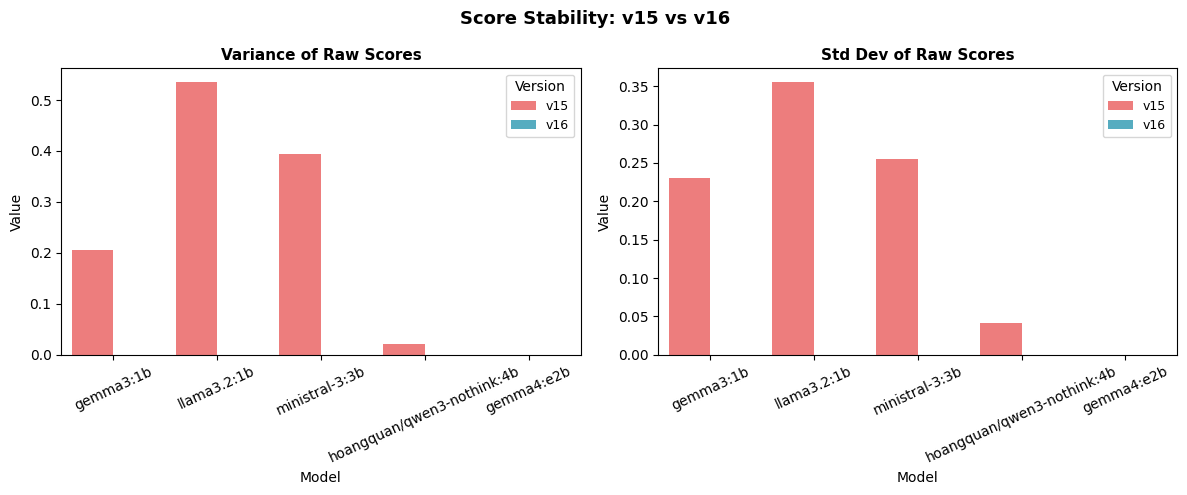

✓ Stability metrics comparison created


In [115]:
# 6.2 Variance & StdDev of Raw Scores: v15 vs v16
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

variance_metrics = {
    'Variance_Raw_Score': 'Variance of Raw Scores',
    'StdDev_Raw_Score': 'Std Dev of Raw Scores'
}

for idx, (metric, title) in enumerate(variance_metrics.items()):
    var_data = []
    for model in df_v15v16['Model_Display'].dropna().unique():
        for version in ['v15', 'v16']:
            subset = df_v15v16[
                (df_v15v16['Summary_Metric'] == metric) & 
                (df_v15v16['Prompt_Ver'] == version) &
                (df_v15v16['Model_Display'] == model)
            ]['Value'].dropna().tolist()
            if subset:
                var_data.append({
                    'Model': model,
                    'Version': version,
                    'Value': np.mean(subset)
                })
    
    if var_data:
        var_df = pd.DataFrame(var_data)
        sns.barplot(data=var_df, x='Model', y='Value', hue='Version',
                    palette=['#FF6B6B', '#45B7D1'], ax=axes[idx])
        axes[idx].set_title(f'{title}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Value')
        axes[idx].tick_params(axis='x', rotation=25)
        axes[idx].legend(title='Version', fontsize=9)

plt.suptitle('Score Stability: v15 vs v16', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Stability metrics comparison created")

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime, timedelta

# Filter the existing melted data for May 8th onwards and v15/v16
offset_date = pd.Timestamp('2026-05-08')
df_v15v16 = df_melted[
    (df_melted['Timestamp'] >= offset_date) & 
    (df_melted['Prompt_Ver'].isin(['v15', 'v16']))
].copy()

# Normalize the display label for the qwen model alias used in notes and charts.
df_v15v16['Model_Display'] = df_v15v16['Model'].replace({
    'hoangquan456/qwen3-nothink:4b': 'hoangquan/qwen3-nothink:4b'
})

print(f"Single Agent Evaluation Data (v15 & v16, May 8+):")
print(f"  Total rows: {len(df_v15v16)}")
print(f"  Date range: {df_v15v16['Timestamp'].min()} to {df_v15v16['Timestamp'].max()}")
print(f"  Versions: {df_v15v16['Prompt_Ver'].unique()}")
print(f"  Models: {df_v15v16['Model'].nunique()} models")
print(f"  Normalized labels: {sorted(df_v15v16['Model_Display'].dropna().astype(str).unique().tolist())}")
print(f"  Domains: {df_v15v16['Domain'].nunique()} domains")
print(f"  Metrics: {df_v15v16['Summary_Metric'].nunique()} unique metrics")

Single Agent Evaluation Data (v15 & v16, May 8+):
  Total rows: 4624
  Date range: 2026-05-08 00:04:03 to 2026-05-10 23:07:57
  Versions: <StringArray>
['v15', 'v16']
Length: 2, dtype: str
  Models: 5 models
  Normalized labels: ['gemma3:1b', 'gemma4:e2b', 'hoangquan/qwen3-nothink:4b', 'llama3.2:1b', 'ministral-3:3b']
  Domains: 26 domains
  Metrics: 25 unique metrics


## 6. Sys-Prompt Version Comparison (v15 vs v16)
**Comparison:** Detailed metrics for system prompt versions v15 and v16 across all models and domains.
*   **Charts:** Easy-to-understand visualizations comparing accuracy, efficiency, stability, and reasoning metrics.

May 9+ Data Summary:
  Total rows: 4284
  Date range: 2026-05-09 00:09:09 to 2026-05-10 23:07:57
  Models: ['gemma3:1b', 'gemma4:e2b', 'hoangquan/qwen3-nothink:4b', 'llama3.2:1b', 'ministral-3:3b']


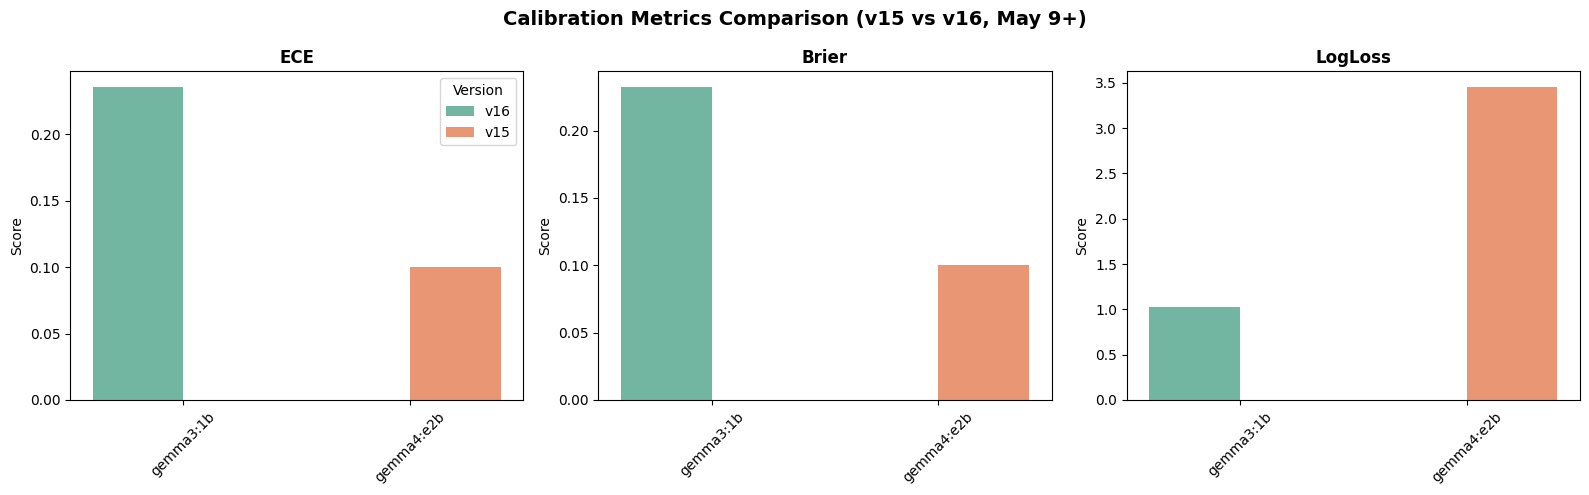

✓ Calibration metrics comparison created
Using F1 metric: Average_Evidence_F1


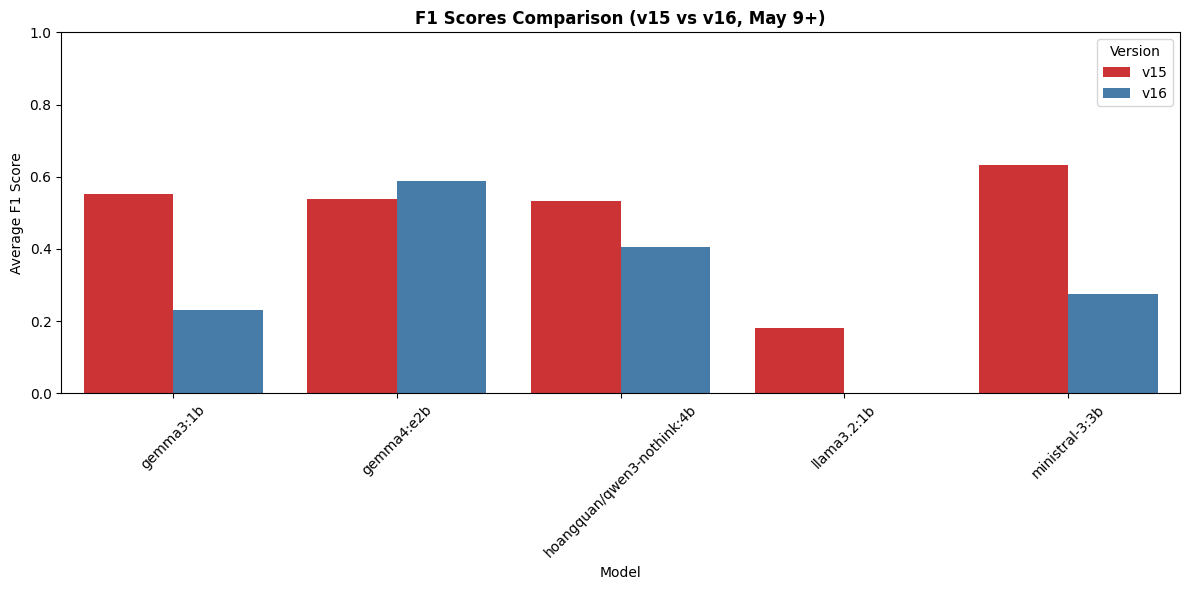

✓ F1 scores comparison created


In [124]:
# Create filtered data for May 9th onwards
cutoff_may9 = pd.Timestamp('2026-05-09')
df_may9 = df_melted[
    (df_melted['Timestamp'] >= cutoff_may9) &
    (df_melted['Prompt_Ver'].isin(['v15', 'v16']))
].copy()

# Normalize model labels
df_may9['Model_Display'] = df_may9['Model'].replace({
    'hoangquan456/qwen3-nothink:4b': 'hoangquan/qwen3-nothink:4b'
})

print(f"May 9+ Data Summary:")
print(f"  Total rows: {len(df_may9)}")
print(f"  Date range: {df_may9['Timestamp'].min()} to {df_may9['Timestamp'].max()}")
print(f"  Models: {sorted(df_may9['Model_Display'].dropna().astype(str).unique().tolist())}")

# Define calibration and F1 metrics to visualize
calib_metrics = ['Average_Calibration_ECE', 'Average_Calibration_Brier', 'Average_Calibration_LogLoss']
f1_metric_candidates = ['Average_Evidence_F1', 'Average_F1_Macro']

# Prepare data for calibration metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Calibration Metrics Comparison (v15 vs v16, May 9+)', fontsize=14, fontweight='bold')

for idx, metric in enumerate(calib_metrics):
    metric_data = df_may9[df_may9['Summary_Metric'] == metric]

    if len(metric_data) == 0:
        axes[idx].text(0.5, 0.5, f'No data for {metric}', ha='center', va='center')
        axes[idx].set_title(metric.replace('Average_Calibration_', ''))
        continue

    # Create grouped bar chart
    plot_data = []
    models = sorted(metric_data['Model_Display'].dropna().unique())

    for model in models:
        for version in ['v15', 'v16']:
            subset = metric_data[
                (metric_data['Model_Display'] == model) &
                (metric_data['Prompt_Ver'] == version)
            ]['Value'].mean()

            if not pd.isna(subset):
                plot_data.append({'Model': model, 'Version': version, 'Value': subset})

    if plot_data:
        plot_df = pd.DataFrame(plot_data)
        sns.barplot(data=plot_df, x='Model', y='Value', hue='Version', ax=axes[idx], palette='Set2')
        axes[idx].set_title(metric.replace('Average_Calibration_', ''), fontweight='bold')
        axes[idx].set_xlabel('')
        axes[idx].set_ylabel('Score')
        axes[idx].tick_params(axis='x', rotation=45)
        if idx == 0:
            axes[idx].legend(title='Version', loc='best')
        else:
            axes[idx].legend_.remove()

plt.tight_layout()
plt.show()
print("✓ Calibration metrics comparison created")

# Prepare data for F1 scores (use a single, pre-aggregated table to keep plotting fast)
available_f1 = [m for m in f1_metric_candidates if m in df_may9['Summary_Metric'].unique()]
if not available_f1:
    f1_metric = None
    f1_source = pd.DataFrame()
    f1_summary = pd.DataFrame()
    f1_models = []
    f1_versions = []
    print("⚠ No F1 metrics found in the May 9+ dataset")
else:
    f1_metric = available_f1[0]
    f1_source = df_may9[df_may9['Summary_Metric'] == f1_metric].copy()
    f1_source['Value'] = pd.to_numeric(f1_source['Value'], errors='coerce')
    f1_source = f1_source.dropna(subset=['Value']).copy()

    if f1_source.empty:
        f1_summary = pd.DataFrame()
        f1_models = []
        f1_versions = []
        print(f"⚠ No non-null values found for {f1_metric}")
    else:
        f1_summary = (
            f1_source.groupby(['Model_Display', 'Prompt_Ver'], as_index=False)['Value']
            .mean()
            .rename(columns={'Value': 'F1 Score'})
        )
        f1_models = sorted(f1_summary['Model_Display'].dropna().unique().tolist())
        f1_versions = [v for v in ['v15', 'v16'] if v in f1_summary['Prompt_Ver'].unique()]
        print(f"Using F1 metric: {f1_metric}")

if f1_metric and not f1_summary.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=f1_summary,
        x='Model_Display',
        y='F1 Score',
        hue='Prompt_Ver',
        order=f1_models,
        hue_order=f1_versions,
        ax=ax,
        palette='Set1'
    )
    ax.set_title('F1 Scores Comparison (v15 vs v16, May 9+)', fontweight='bold', fontsize=12)
    ax.set_xlabel('Model')
    ax.set_ylabel('Average F1 Score')
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Version', loc='best')
    plt.tight_layout()
    plt.show()
    print("✓ F1 scores comparison created")

In [ ]:
# Diagnostic: Check F1 data availability for llama3.2:1b v16
print("="*80)
print("DIAGNOSTIC: F1 Data Availability for llama3.2:1b")
print("="*80)

if 'f1_metric' not in globals() or f1_metric is None:
    print("No F1 metric selected in the previous cell.")
elif 'f1_source' not in globals() or f1_source.empty:
    print(f"No data available for {f1_metric}.")
else:
    llama_f1 = f1_source[f1_source['Model_Display'] == 'llama3.2:1b'].copy()

    print(f"\nTotal F1 rows for llama3.2:1b (May 9+): {len(llama_f1)}")
    print(f"Metric used: {f1_metric}")
    print(f"Versions in F1 data: {sorted(llama_f1['Prompt_Ver'].dropna().unique().tolist())}")
    print("\nBreakdown by version:")
    breakdown = llama_f1.groupby(['Prompt_Ver']).size()
    print(breakdown)

    print("\nDetailed view (v16):")
    v16_f1 = llama_f1[llama_f1['Prompt_Ver'] == 'v16']
    print(f"  Rows: {len(v16_f1)}")
    if len(v16_f1) > 0:
        print(f"  Domains: {v16_f1['Domain'].nunique()}")
        print(f"  Value samples: {v16_f1['Value'].head().tolist()}")
        print(f"  Non-null values: {v16_f1['Value'].notna().sum()}")
    else:
        print("  NO DATA FOUND")

print("\n" + "="*80)

DIAGNOSTIC: F1 Data Availability for llama3.2:1b

Total F1 rows for llama3.2:1b (May 9+): 28
Metrics found: ['Average_Evidence_F1']
Versions in F1 data: ['v15', 'v16']

Breakdown by version and metric:
Prompt_Ver  Summary_Metric     
v15         Average_Evidence_F1    12
v16         Average_Evidence_F1    16
dtype: int64

Detailed view (v16 + Average_Evidence_F1):
  Rows: 16
  Domains: 8
  Value samples: [0.0, 0.0, 0.0, 0.0, 0.0]
  Non-null values: 16



In [ ]:
# Show what values are being plotted for the F1 chart
print("\nF1 PLOT DATA - What was aggregated:")
print("-" * 80)

if 'f1_summary' not in globals() or f1_summary.empty:
    print("No F1 summary table available. Run the F1 prep cell first.")
else:
    for _, row in f1_summary.sort_values(['Model_Display', 'Prompt_Ver']).iterrows():
        print(f"{row['Model_Display']:30s} | {row['Prompt_Ver']:3s} | F1 = {row['F1 Score']:.4f}")

    print("\nSummary table:")
    print(f1_summary.sort_values(['Model_Display', 'Prompt_Ver']).to_string(index=False))


F1 PLOT DATA - What was aggregated:
--------------------------------------------------------------------------------
gemma3:1b                      | v15 | F1 = 0.5520
gemma3:1b                      | v16 | F1 = 0.2315
gemma4:e2b                     | v15 | F1 = 0.5379
gemma4:e2b                     | v16 | F1 = 0.5871
hoangquan/qwen3-nothink:4b     | v15 | F1 = 0.5321
hoangquan/qwen3-nothink:4b     | v16 | F1 = 0.4048
llama3.2:1b                    | v15 | F1 = 0.1809
llama3.2:1b                    | v16 | F1 = 0.0000
ministral-3:3b                 | v15 | F1 = 0.6325
ministral-3:3b                 | v16 | F1 = 0.2746

Summary table:
                     Model Version  F1 Score
                 gemma3:1b     v15  0.552000
                 gemma3:1b     v16  0.231508
                gemma4:e2b     v15  0.537922
                gemma4:e2b     v16  0.587144
hoangquan/qwen3-nothink:4b     v15  0.532080
hoangquan/qwen3-nothink:4b     v16  0.404836
               llama3.2:1b     v15  0.180


F1 SCORES - WITH ZERO VALUE HIGHLIGHTING:


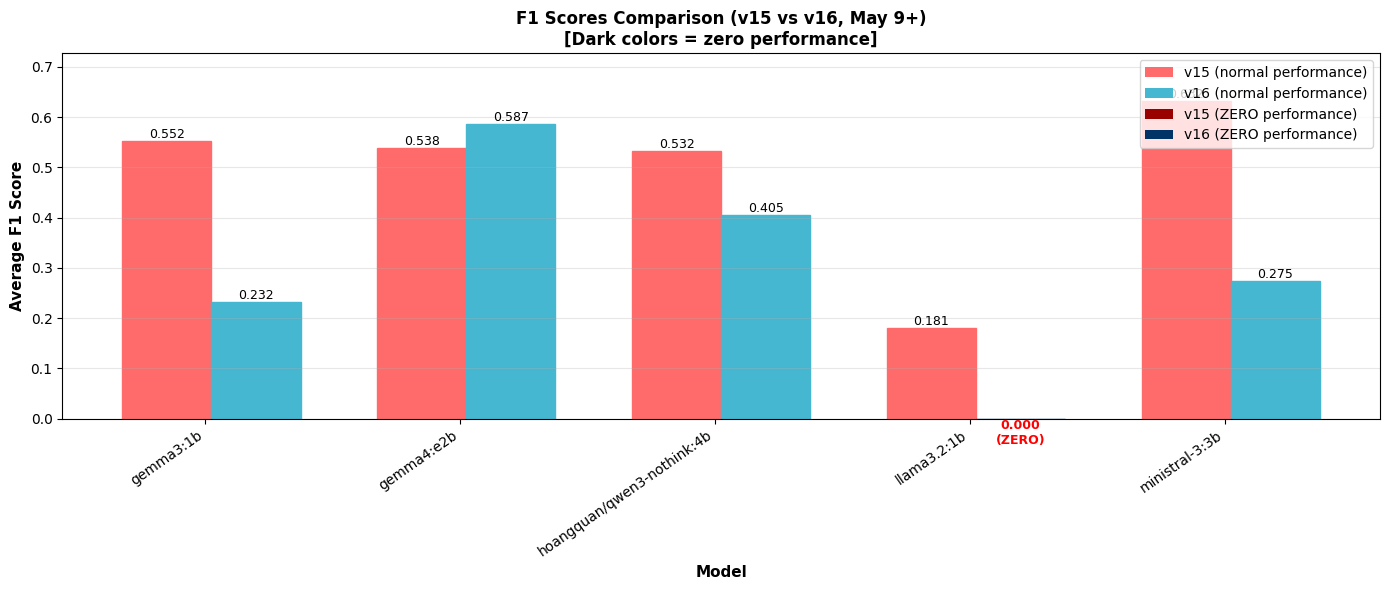


✓ F1 scores with zero highlighting created

Key Finding: llama3.2:1b v16 has ZERO F1 score across all domains!


In [ ]:
# F1 Scores with highlighting for zero values
print("\nF1 SCORES - WITH ZERO VALUE HIGHLIGHTING:")
print("="*80)

if 'f1_summary' not in globals() or f1_summary.empty:
    print("No F1 summary table available. Run the F1 prep cell first.")
else:
    plot_df = f1_summary.copy()
    if 'f1_models' in globals() and f1_models:
        plot_df['Model_Display'] = pd.Categorical(plot_df['Model_Display'], categories=f1_models, ordered=True)
        plot_df = plot_df.sort_values('Model_Display')

    # Pivot to wide for easier bar plotting and zero highlighting
    wide_df = plot_df.pivot_table(
        index='Model_Display',
        columns='Prompt_Ver',
        values='F1 Score',
        aggfunc='mean'
    ).reset_index()

    # Ensure both columns exist for plotting
    for version in ['v15', 'v16']:
        if version not in wide_df.columns:
            wide_df[version] = 0.0

    wide_df = wide_df.fillna(0.0)

    fig, ax = plt.subplots(figsize=(14, 6))

    x = range(len(wide_df))
    v15_vals = wide_df['v15'].tolist()
    v16_vals = wide_df['v16'].tolist()

    bar1 = ax.bar([i - 0.2 for i in x], v15_vals, width=0.35, label='v15')
    bar2 = ax.bar([i + 0.2 for i in x], v16_vals, width=0.35, label='v16')

    # Apply colors (dark for zero)
    for bar, val in zip(bar1, v15_vals):
        bar.set_color('#FF6B6B' if val > 0 else '#990000')
    for bar, val in zip(bar2, v16_vals):
        bar.set_color('#45B7D1' if val > 0 else '#003366')

    # Add value labels
    for bar in list(bar1) + list(bar2):
        height = bar.get_height()
        label_text = f'{height:.3f}' + ('\n(ZERO)' if height == 0 else '')
        va = 'bottom' if height > 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2., height, label_text, ha='center', va=va, fontsize=9)

    ax.set_ylabel('Average F1 Score', fontsize=11, fontweight='bold')
    ax.set_xlabel('Model', fontsize=11, fontweight='bold')
    ax.set_title('F1 Scores Comparison (v15 vs v16, May 9+)\n[Dark colors = zero performance]',
                 fontweight='bold', fontsize=12)
    ax.set_xticks(list(x))
    ax.set_xticklabels(wide_df['Model_Display'].astype(str).tolist(), rotation=35, ha='right')
    ax.set_ylim([0, max(max(v15_vals + v16_vals) * 1.15, 0.7)])
    ax.grid(axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#FF6B6B', label='v15 (normal performance)'),
        Patch(facecolor='#45B7D1', label='v16 (normal performance)'),
        Patch(facecolor='#990000', label='v15 (ZERO performance)'),
        Patch(facecolor='#003366', label='v16 (ZERO performance)')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

    print("\n✓ F1 scores with zero highlighting created")